In [28]:
#read data
data = '/Users/hoanglinh/Library/Mobile Documents/com~apple~CloudDocs/Important/Job applications/Github/EVT/Macroeconomics and FTSE100.csv'

In [173]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pyextremes import EVA, plot_mean_residual_life, plot_threshold_stability

#import libraries for regression model
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression

In [30]:
df = pd.read_csv(data)
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5053 entries, 0 to 5052
Data columns (total 9 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Date                                    5053 non-null   datetime64[ns]
 1   Spot exchange rate, US $ into Sterling  5053 non-null   float64       
 2   FTSE100 daily return                    5053 non-null   float64       
 3   10Y yield                               5053 non-null   float64       
 4   yield-curve                             5053 non-null   float64       
 5   bank rate                               5053 non-null   float64       
 6   CPI                                     5053 non-null   float64       
 7   GDP                                     5053 non-null   float64       
 8   Unemployment                            5053 non-null   float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 355.4 

/var/folders/y4/1swrb3ns1n5g6cd_1pvgr_6m0000gn/T/ipykernel_99340/3112929055.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [31]:
df = df.rename(columns={
        "Spot exchange rate, US $ into Sterling": "ER",
        "10Y yield": "BY",
        "FTSE100 daily return": "SP",
        "yield-curve": "YC",
        "bank rate": "BR",
        "Unemployment": "UN"})
df["NSP"] = -df["SP"]

df.head()

,Date,ER,SP,BY,YC,BR,CPI,GDP,UN,NSP
0,2024-12-31,0.7982,0.0064,4.517,0.37,4.75,3.5,101.8458,4.4,-0.0064
1,2024-12-30,0.7993,-0.0035,4.594,0.36,4.75,3.5,101.8458,4.4,0.0035
2,2024-12-27,0.7951,0.0016,4.601,0.37,4.75,3.5,101.8458,4.4,-0.0016
3,2024-12-24,0.7975,0.0042,4.634,0.35,4.75,3.5,101.8458,4.4,-0.0042
4,2024-12-23,0.7988,0.0022,4.603,0.35,4.75,3.5,101.8458,4.4,-0.0022


In [32]:
corr_matrix = df.corr()

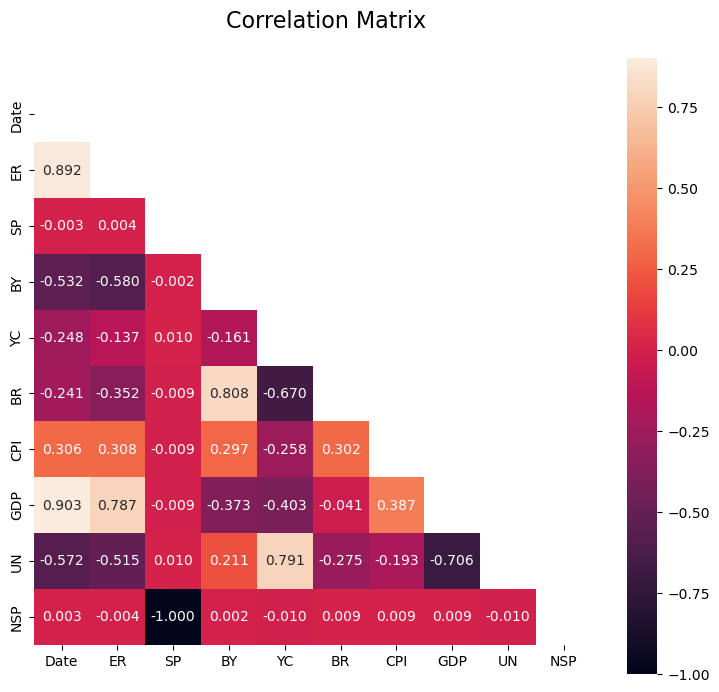

In [33]:
matrix_mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(9,8))
plt.suptitle("Correlation Matrix", fontsize = 16, x = 0.45, y = 0.94)
sns.heatmap(corr_matrix, annot=True, fmt="0.3f", square=True, mask= matrix_mask)

plt.show()

## Extreme Value Analysis

/opt/anaconda3/lib/python3.13/site-packages/pyextremes/eva.py:122: RuntimeWarning: `data` index is not sorted in ascending order - sorting `data` by index
  warnings.warn(message=message, category=RuntimeWarning)


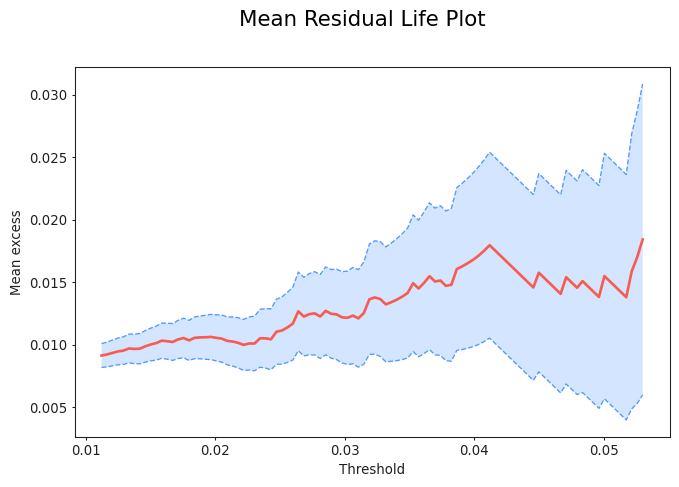

/opt/anaconda3/lib/python3.13/site-packages/pyextremes/eva.py:122: RuntimeWarning: `data` index is not sorted in ascending order - sorting `data` by index
  warnings.warn(message=message, category=RuntimeWarning)
/opt/anaconda3/lib/python3.13/site-packages/pyextremes/eva.py:122: RuntimeWarning: `data` index is not sorted in ascending order - sorting `data` by index
  warnings.warn(message=message, category=RuntimeWarning)
/opt/anaconda3/lib/python3.13/site-packages/pyextremes/eva.py:122: RuntimeWarning: `data` index is not sorted in ascending order - sorting `data` by index
  warnings.warn(message=message, category=RuntimeWarning)
/opt/anaconda3/lib/python3.13/site-packages/pyextremes/eva.py:122: RuntimeWarning: `data` index is not sorted in ascending order - sorting `data` by index
  warnings.warn(message=message, category=RuntimeWarning)
/opt/anaconda3/lib/python3.13/site-packages/pyextremes/eva.py:122: RuntimeWarning: `data` index is not sorted in ascending order - sorting `data` by

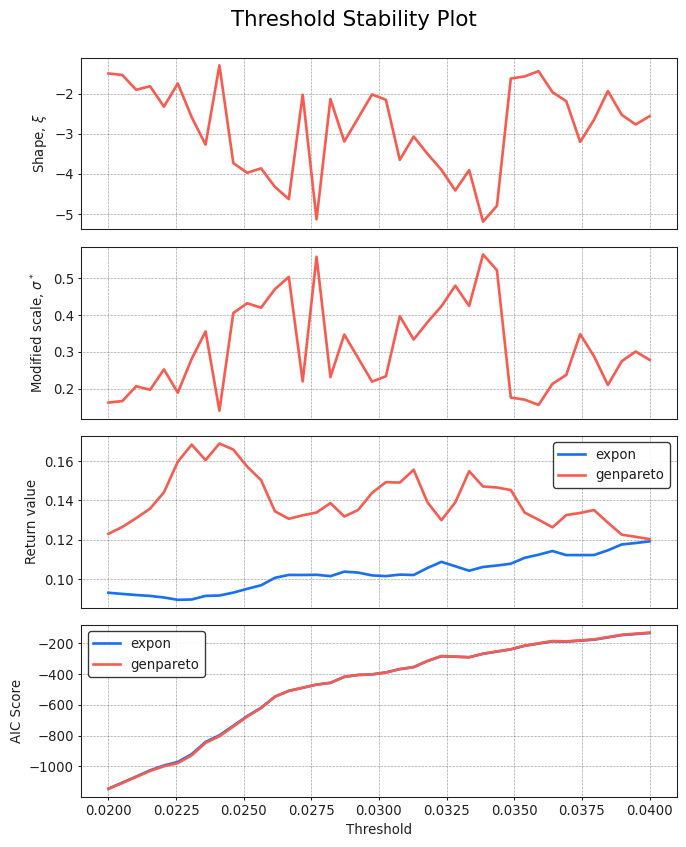

In [103]:
NSP_series = df.set_index("Date")["NSP"]
model = EVA(NSP_series)

#Threshold selection
plot_mean_residual_life(NSP_series)
plt.suptitle("Mean Residual Life Plot", fontsize = 16, x = 0.5, y = 1)
plt.show()

plot_threshold_stability(
    NSP_series, 
    return_period=100, 
    thresholds=np.linspace(0.02, 0.04, 40)
)
plt.suptitle("Threshold Stability Plot", fontsize = 16, x = 0.48, y = 0.93)
plt.show()

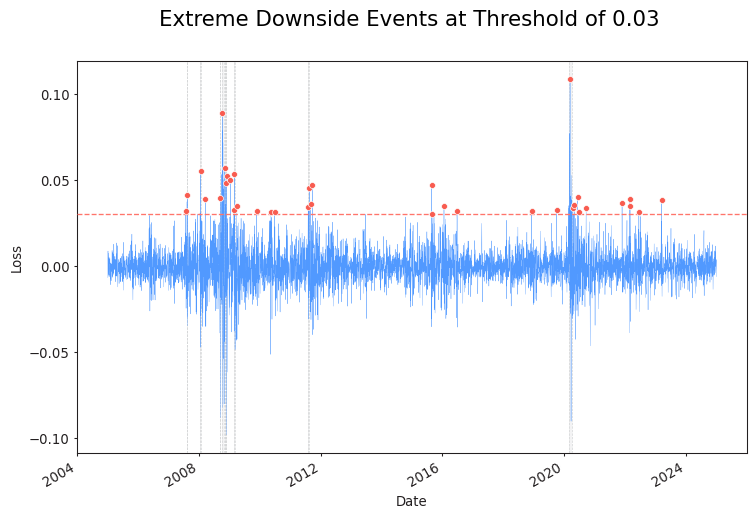

               return value  lower ci  upper ci
return period                                  
1.0                0.035656  0.035445  0.035752
2.0                0.043389  0.042786  0.043334
5.0                0.056371  0.055355  0.056215
10.0               0.068809  0.066195  0.069045
20.0               0.084071  0.080440  0.084083
50.0               0.109691  0.103331  0.108548
100.0              0.134238  0.124487  0.128505


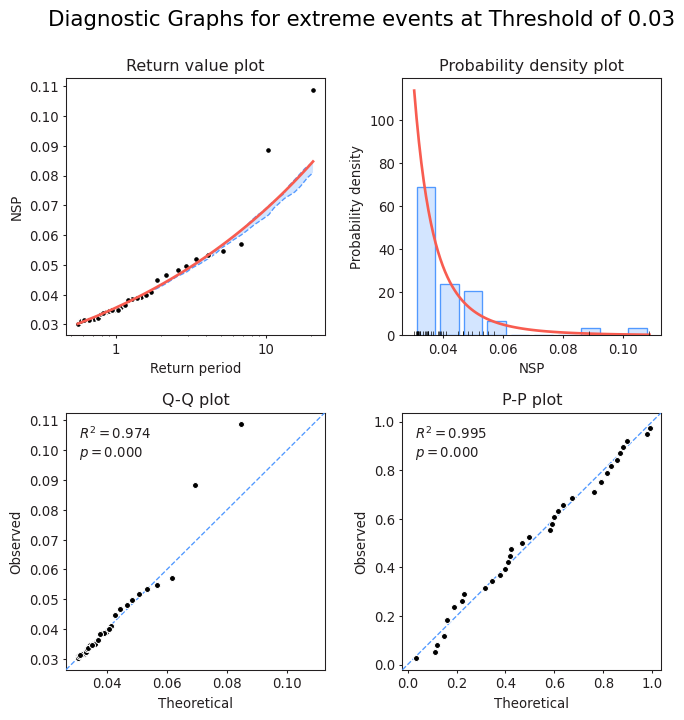

In [ ]:
#Extracting extreme values at threshold of 0.03

model.get_extremes(
    method = "POT", 
    threshold = 0.03, 
    extremes_type = "high",
    r = "7D"
)


model.plot_extremes(show_clusters=True, figsize=(9,6))
plt.suptitle("Extreme Downside Events at Threshold of 0.03", fontsize = 16, x = 0.51, y = 0.97)
plt.xlabel("Date")
plt.ylabel("Loss")
plt.show()


model.fit_model()

summary_1 = model.get_summary(
    return_period= [1, 2, 5, 10, 20, 50, 100],
    alpha = 0.05
)
print(summary_1)

model.plot_diagnostic(alpha=0.05)
plt.suptitle("Diagnostic Graphs for extreme events at Threshold of 0.03", fontsize = 16, x = 0.51, y = 0.97)
plt.show()


##### The return value plot shows that the fitted GPD closely follows the empirical extreme values across different return periods, indicating a good fit of the model in capturing the tail behaviour of losses.
##### The probability density plot indicates that the GPD provides a reasonable approximation of the distribution of extreme losses, capturing the right-skewed and heavy-tailed nature of the data.
##### The Q–Q plot demonstrates a strong alignment between observed and theoretical quantiles, with most points lying close to the 45-degree line. This suggests that the GPD provides a good fit to the extreme values.
##### The P–P plot shows an excellent fit, with observations closely aligned with the theoretical distribution, as reflected by the high R² value of 0.995.

## OLS Regression Model

In [105]:
# Checking for missing data
for col in df.columns:
    missing_data = df[col].isna().sum()
    missing_percent = (missing_data/len(df[col]))*100
    print(f'There are {missing_percent}% of missing data in column {col}')

There are 0.0% of missing data in column Date
There are 0.0% of missing data in column ER
There are 0.0% of missing data in column SP
There are 0.0% of missing data in column BY
There are 0.0% of missing data in column YC
There are 0.0% of missing data in column BR
There are 0.0% of missing data in column CPI
There are 0.0% of missing data in column GDP
There are 0.0% of missing data in column UN
There are 0.0% of missing data in column NSP


In [145]:
df['extreme'] = (df['NSP'] > 0.03).astype('int')

df_extreme = df[df['extreme']==1]
df_extreme.head(5)
df_extreme.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63 entries, 453 to 4404
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     63 non-null     datetime64[ns]
 1   ER       63 non-null     float64       
 2   SP       63 non-null     float64       
 3   BY       63 non-null     float64       
 4   YC       63 non-null     float64       
 5   BR       63 non-null     float64       
 6   CPI      63 non-null     float64       
 7   GDP      63 non-null     float64       
 8   UN       63 non-null     float64       
 9   NSP      63 non-null     float64       
 10  extreme  63 non-null     int64         
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 5.9 KB


In [ ]:
#Prep variables
x_1 = df_extreme[['BR', 'ER', 'BY', 'YC', 'CPI', 'GDP', 'UN']].values
y_1 = df_extreme['NSP'].values

#Fitting model
X_1 = sm.add_constant(x_1)
regr_model2 = sm.OLS(y_1,X_1).fit()

print(regr_model2.summary())

(47, 7) (16, 7) (47,) (16,)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     1.289
Date:                Thu, 09 Apr 2026   Prob (F-statistic):              0.273
Time:                        14:04:19   Log-Likelihood:                 180.07
No. Observations:                  63   AIC:                            -344.1
Df Residuals:                      55   BIC:                            -327.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0416   

##### First, we used OLS model gave use a R-square of 0.141 which can be understand as this model only explain about 14% the data, which means it is not trustable. Moreover, the model can only use 63 observation, which is most likely lead to multicollinearity. Hence, we decided to use another model to compare the result. Second, as can be seen in the summary result, the model gave us the F-statistic of 0.273, which means the model is not significant.

## Logistic Regression Model

In [164]:
#prep the data
x_2 = df[['BR', 'BY', 'YC', 'CPI', 'GDP', 'UN']].values
y_2 = df['extreme'].values

X_2 = sm.add_constant(x_2)
logit_model = sm.Logit(y_2, X_2).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.060266
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 5053
Model:                          Logit   Df Residuals:                     5046
Method:                           MLE   Df Model:                            6
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.1013
Time:                        14:20:24   Log-Likelihood:                -304.52
converged:                       True   LL-Null:                       -338.84
Covariance Type:            nonrobust   LLR p-value:                 7.832e-13
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.9773      2.348      5.526      0.000       8.375      17.580
x1             1.5823      0.

##### The Logistic Regression model gave us a model using Maximum Likelihood Estimation (MLE) which fits the binary outcome better than using Least Squares. Also, as can be seen the model has LL-Null smaller than Log-Likelihood, which means this model has a better fit than other ones. Not only that, the model also has a high significant of p-value at 7.832e-13, and it also has 0.1013 of Pseudo R-squared, which can be explained as the model shows a modest improvement in fit relative to the null model.
##### Moreover, we can see, the result indicates that several macroeconomic variables significantly influence the probability of extreme downside events in the FTSE 100. In particular, higher interest rates and inflation are associated with an increased likelihood of extreme losses